In [1]:
import pandas as pd

trades = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\PRIMETRADE AI TASK\historical_data.csv")

sentiment = pd.read_csv(r"C:\Users\HP\OneDrive\Documents\PRIMETRADE AI TASK\fear_greed_index.csv")

In [3]:
print(trades.head())

print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [4]:
print(trades.columns)

print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [5]:
print(trades.isnull().sum())

print(sentiment.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [6]:
print(trades.info())

print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

sentiment['date'] = pd.to_datetime(sentiment['date'])

In [8]:
trades['date_only'] = trades['Timestamp'].dt.date

sentiment['date_only'] = sentiment['date'].dt.date

In [9]:
merged = pd.merge(
    trades,
    sentiment,
    on='date_only',
    how='left'
)

In [10]:
print(merged.head())

print(merged.columns)

print(merged['classification'].value_counts())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  52017706630     

In [11]:
print(merged[['Closed PnL', 'Execution Price', 'Size USD', 'Fee']].describe())

          Closed PnL  Execution Price      Size USD            Fee
count  211224.000000    211224.000000  2.112240e+05  211224.000000
mean       48.749001     11414.723350  5.639451e+03       1.163967
std       919.164828     29447.654868  3.657514e+04       6.758854
min   -117990.104100         0.000005  0.000000e+00      -1.175712
25%         0.000000         4.854700  1.937900e+02       0.016121
50%         0.000000        18.280000  5.970450e+02       0.089578
75%         5.792797       101.580000  2.058960e+03       0.393811
max    135329.090100    109004.000000  3.921431e+06     837.471593


**Average Profit by Sentiment**

In [12]:
print(
    merged.groupby('classification')['Closed PnL'].mean()
)

Series([], Name: Closed PnL, dtype: float64)


**Trade count by Sentiment**

In [13]:
print(
    merged.groupby('classification').size()
)

Series([], dtype: int64)


**Buy vs sell analysis**

In [14]:
print(
    merged.groupby(['classification', 'Side'])['Closed PnL'].mean()
)

Series([], Name: Closed PnL, dtype: float64)


**Win rate analysis**

In [15]:
merged['win'] = merged['Closed PnL'] > 0

In [16]:
print(
    merged.groupby('classification')['win'].mean()
)

Series([], Name: win, dtype: float64)


In [17]:
print(merged[['Closed PnL', 'classification']].dtypes)

Closed PnL        float64
classification     object
dtype: object


In [18]:
print(merged['classification'].isnull().sum())

211224


In [19]:
print(
    merged['classification'].value_counts(dropna=False)
)

classification
NaN    211224
Name: count, dtype: int64


In [20]:
merged = merged.dropna(subset=['classification'])

In [21]:
print(merged.shape)

print(merged['classification'].value_counts())

(0, 22)
Series([], Name: count, dtype: int64)


In [22]:
print(trades['Timestamp'].head(10))

0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
5   1970-01-01 00:28:50
6   1970-01-01 00:28:50
7   1970-01-01 00:28:50
8   1970-01-01 00:28:50
9   1970-01-01 00:28:50
Name: Timestamp, dtype: datetime64[ns]


In [23]:
trades = pd.read_csv(
    r"C:\Users\HP\OneDrive\Documents\PRIMETRADE AI TASK\historical_data.csv"
)

In [24]:
print(trades['Timestamp'].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


In [25]:
trades['Timestamp'] = pd.to_datetime(
    trades['Timestamp'],
    unit='ms'
)

print(trades['Timestamp'].head())

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]


In [26]:
trades['date_only'] = trades['Timestamp'].dt.strftime('%Y-%m-%d')

sentiment['date_only'] = pd.to_datetime(
    sentiment['date']
).dt.strftime('%Y-%m-%d')

print(trades['date_only'].head())

print(sentiment['date_only'].head())

0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: date_only, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date_only, dtype: object


In [27]:
print(sentiment['date_only'].tail())

2639    2025-04-28
2640    2025-04-29
2641    2025-04-30
2642    2025-05-01
2643    2025-05-02
Name: date_only, dtype: object


In [28]:
merged = pd.merge(
    trades,
    sentiment[['date_only', 'classification']],
    on='date_only',
    how='inner'
)

print(merged.shape)

print(merged['classification'].value_counts())

(184263, 18)
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64


**VISUALIZATIONS**

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

**Average Closed PnL by Market Sentiment**

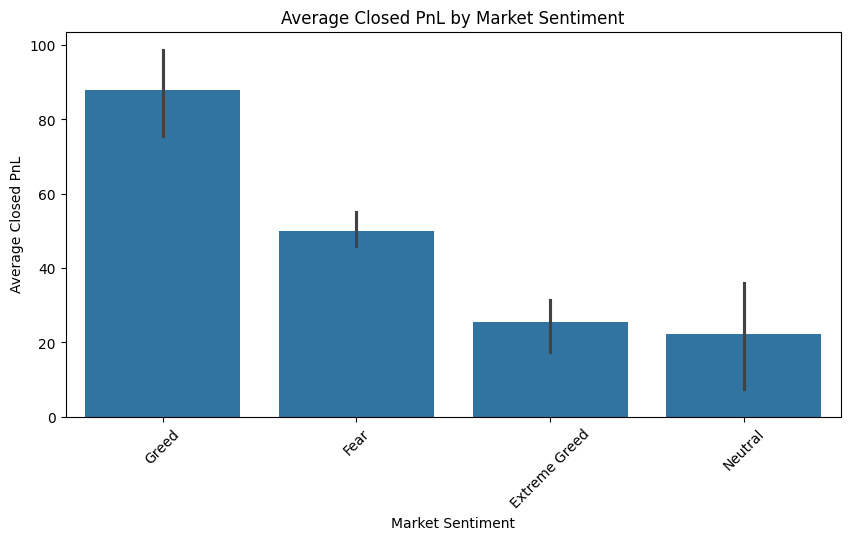

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('Average Closed PnL by Market Sentiment')

plt.xlabel('Market Sentiment')

plt.ylabel('Average Closed PnL')

plt.xticks(rotation=45)

plt.show()

**Number of Trades by Market Sentiment**

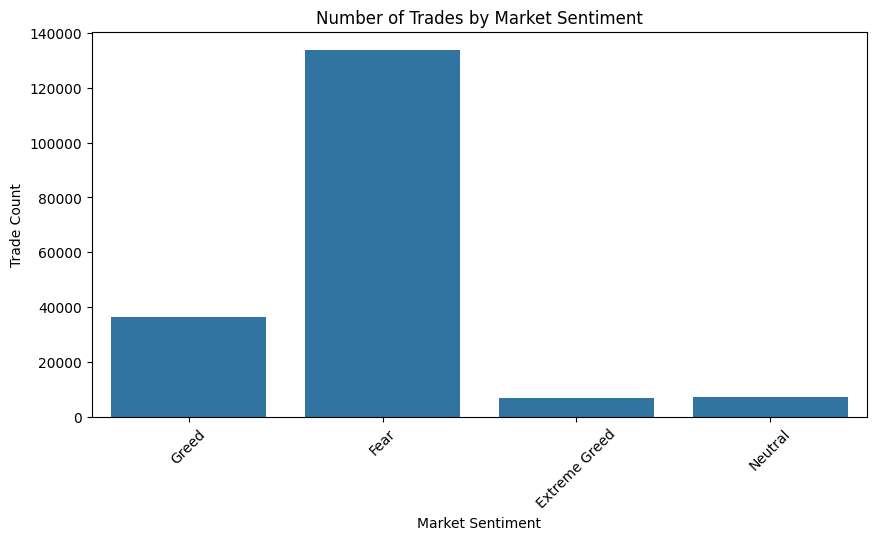

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x='classification'
)

plt.title('Number of Trades by Market Sentiment')

plt.xlabel('Market Sentiment')

plt.ylabel('Trade Count')

plt.xticks(rotation=45)

plt.show()

**Buy vs Sell Performance Across Market Sentiments**

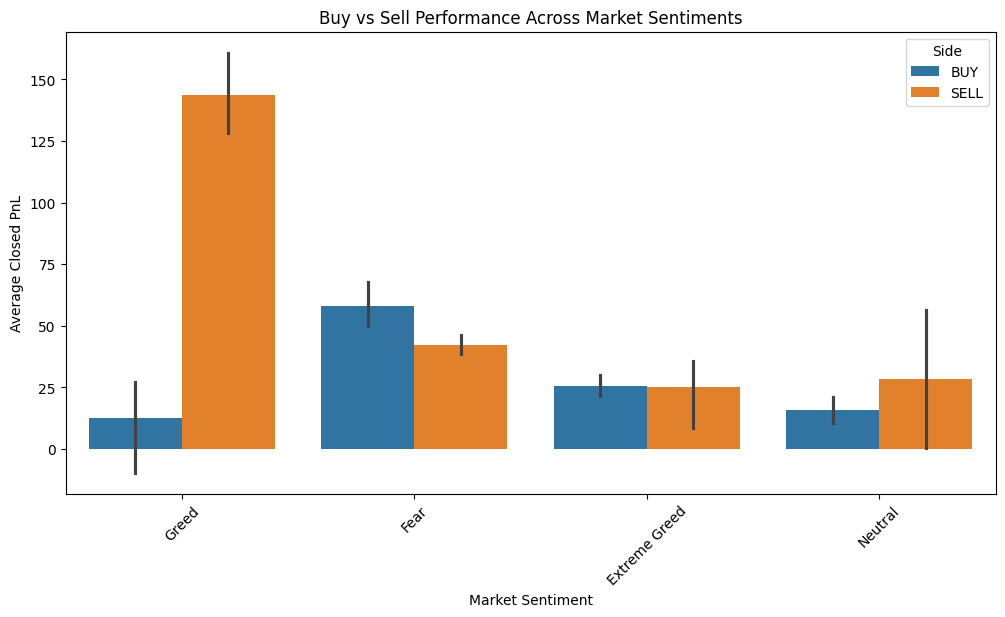

In [32]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=merged,
    x='classification',
    y='Closed PnL',
    hue='Side'
)

plt.title('Buy vs Sell Performance Across Market Sentiments')

plt.xlabel('Market Sentiment')

plt.ylabel('Average Closed PnL')

plt.xticks(rotation=45)

plt.show()

**PnL Distribution Across Market Sentiments**

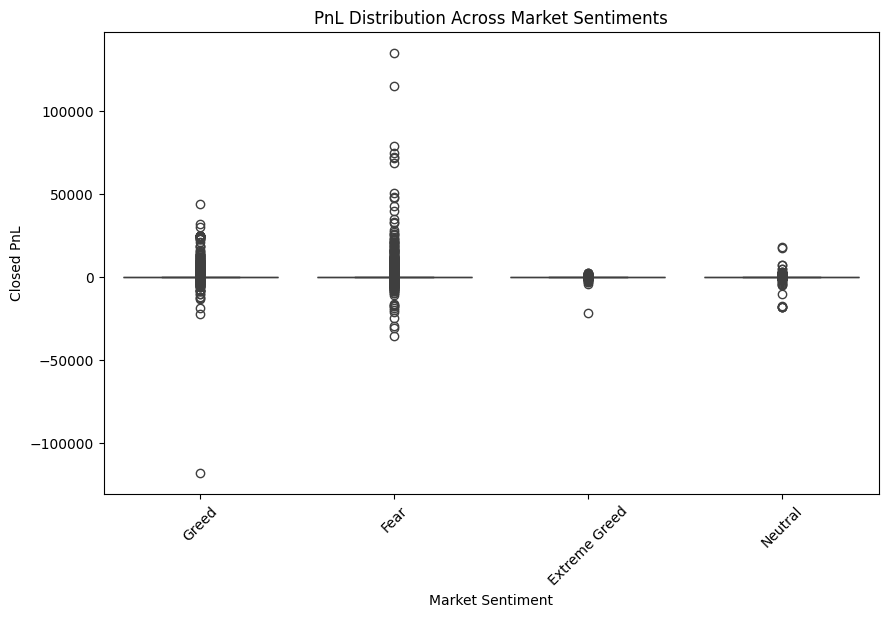

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution Across Market Sentiments')

plt.xlabel('Market Sentiment')

plt.ylabel('Closed PnL')

plt.xticks(rotation=45)

plt.show()

**Correlation Heatmap**

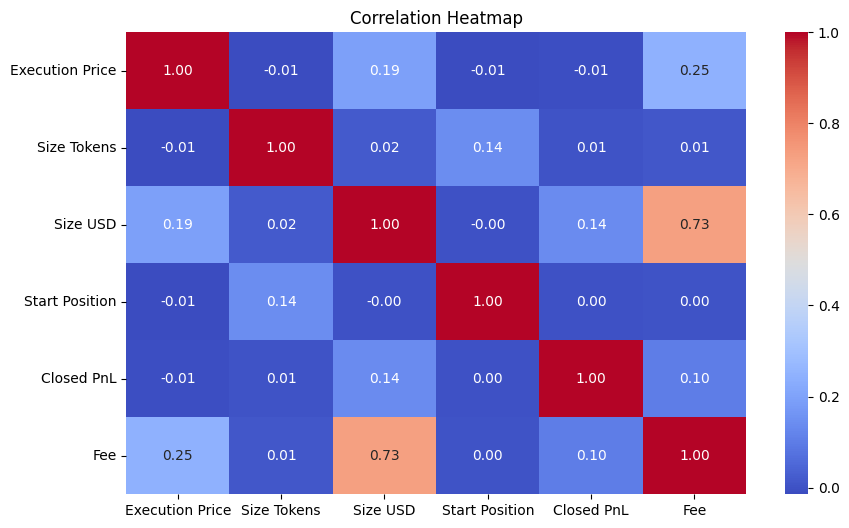

In [34]:
numeric_cols = [
    'Execution Price',
    'Size Tokens',
    'Size USD',
    'Start Position',
    'Closed PnL',
    'Fee'
]

correlation = merged[numeric_cols].corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [35]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby(
    'classification'
)['win'].mean() * 100

print(win_rate)

classification
Extreme Greed    49.008905
Fear             41.514592
Greed            44.647138
Neutral          31.718247
Name: win, dtype: float64


### Daily PnL per Trader

In [37]:
daily_pnl = merged.groupby(
    ["date_only", "Account"]
)["Closed PnL"].sum().reset_index()

daily_pnl.head()

,date_only,Account,Closed PnL
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000


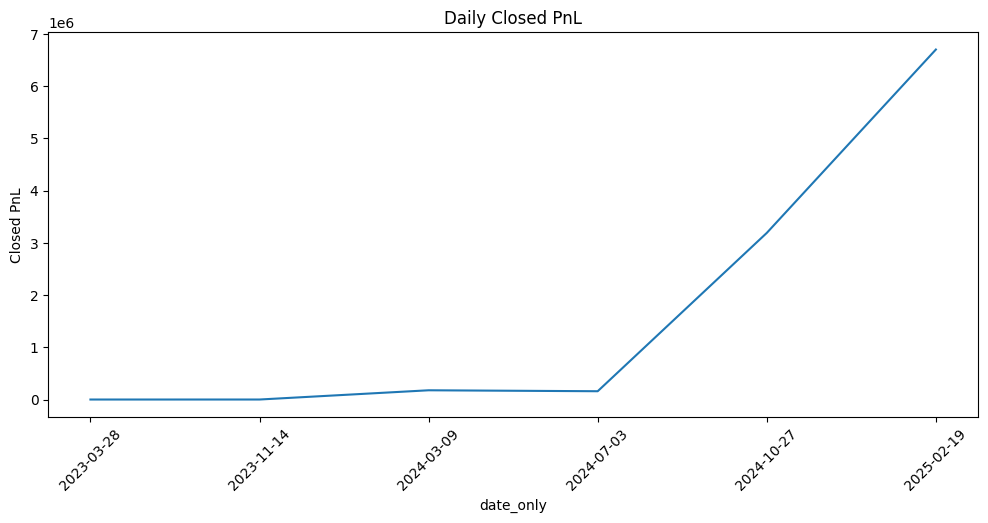

In [44]:
daily_summary = merged.groupby("date_only")["Closed PnL"].sum().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_summary,
    x="date_only",
    y="Closed PnL"
)

plt.xticks(rotation=45)

plt.title("Daily Closed PnL")

plt.show()

### Number of Trades Per day

In [42]:
trades_per_day = merged.groupby("date_only").size().reset_index(name="Trade Count")

print(trades_per_day.head())

    date_only  Trade Count
0  2023-03-28            3
1  2023-11-14         1045
2  2024-03-09         6962
3  2024-07-03         7141
4  2024-10-27        35241


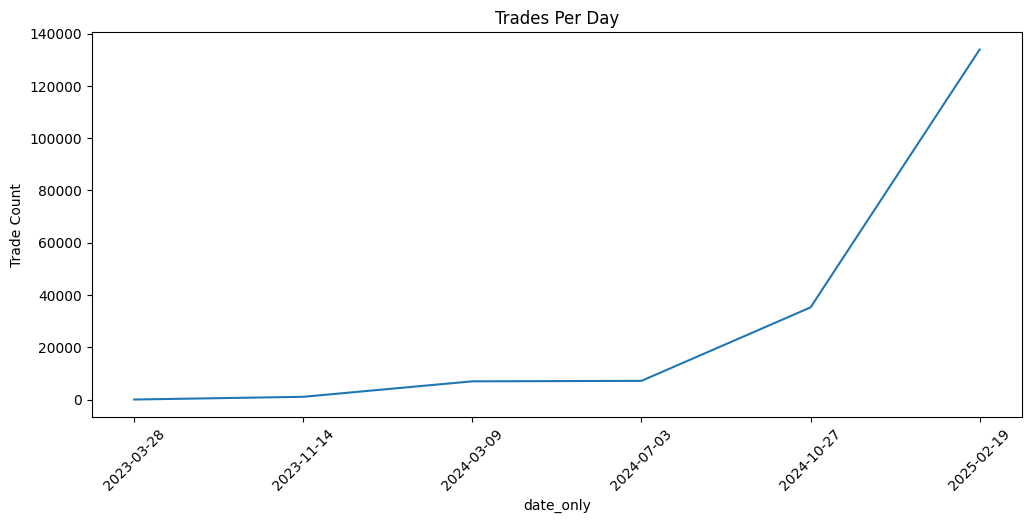

In [43]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=trades_per_day,
    x="date_only",
    y="Trade Count"
)

plt.xticks(rotation=45)

plt.title("Trades Per Day")

plt.show()

### Average trade size

In [38]:
avg_trade = merged.groupby("Account")["Size USD"].mean()

avg_trade.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1759.743439
0x271b280974205ca63b716753467d5a371de622ab    10908.183944
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      509.016502
0x2c229d22b100a7beb69122eed721cee9b24011dd     3142.909573
Name: Size USD, dtype: float64

### Long / Short Ratio

In [39]:
pd.crosstab(
    merged["classification"],
    merged["Side"],
    normalize="index"
)

Side,BUY,SELL
classification,,
Extreme Greed,0.484200,0.515800
Fear,0.493617,0.506383
Greed,0.424950,0.575050
Neutral,0.490828,0.509172


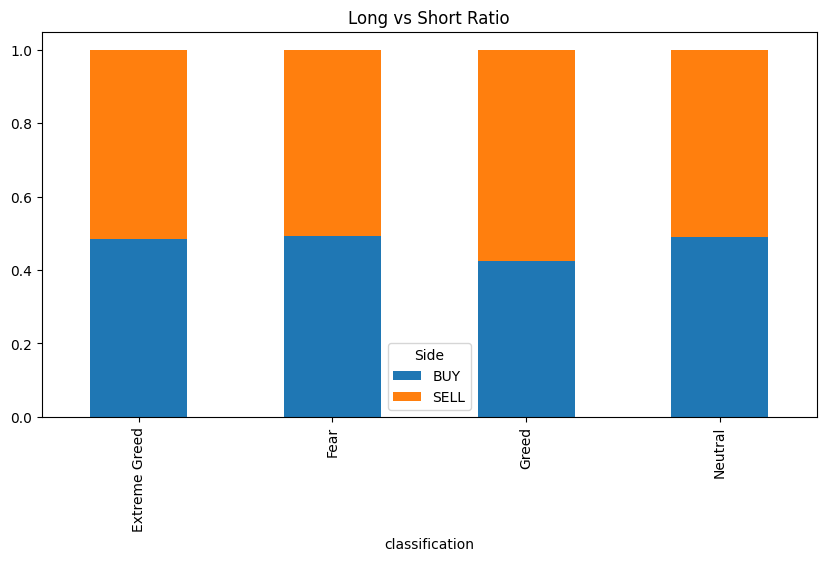

In [45]:
ratio = pd.crosstab(
    merged["classification"],
    merged["Side"],
    normalize="index"
)

ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.title("Long vs Short Ratio")

plt.show()

### Trader Segmentation

In [40]:
trade_count = merged.groupby("Account").size()

threshold = trade_count.quantile(0.75)

frequent = trade_count >= threshold

### Consistent Winners

In [41]:
win_rate = merged.groupby("Account")["win"].mean()

consistent = win_rate > 0.6

**SAVING ALL PLOTS AND CHARTS**

In [46]:
# 1
plt.savefig('1_avg_pnl_by_sentiment.png', bbox_inches='tight')

# 2
plt.savefig('2_trade_count_by_sentiment.png', bbox_inches='tight')

# 3
plt.savefig('3_buy_vs_sell_performance.png', bbox_inches='tight')

# 4
plt.savefig('4_pnl_distribution_boxplot.png', bbox_inches='tight')

# 5
plt.savefig('5_correlation_heatmap.png', bbox_inches='tight')

# 6
plt.savefig('6_daily_pnl.png', dpi=300, bbox_inches='tight')

# 7
plt.savefig('7_trades_per_day.png', dpi=300, bbox_inches='tight')

# 8
plt.savefig('8_long_short_ratio.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>